# P1 – Onderzoek van de Database
## Experimenteer met Jupyter Notebook en laad de MNIST-database

**Leerdoelen:**
- MNIST laden in Jupyter
- Afbeeldingen bekijken
- Data beschrijven i.p.v. alleen gebruiken
- Kritisch nadenken over ML-problemen

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

print('Imports geslaagd!')

Imports geslaagd!


## 2. MNIST laden

De MNIST-dataset bevat 70.000 handgeschreven cijfers (0-9).
Keras downloadt de data automatisch de eerste keer (~11 MB).

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print('=== Dataset geladen ===')
print('Trainingsset afbeeldingen :', X_train.shape)
print('Trainingsset labels       :', y_train.shape)
print('Testset afbeeldingen      :', X_test.shape)
print('Testset labels            :', y_test.shape)
print('Pixelwaarden: min =', X_train.min(), ', max =', X_train.max())
print('Unieke klassen:', np.unique(y_train))

=== Dataset geladen ===
Trainingsset afbeeldingen : (60000, 28, 28)
Trainingsset labels       : (60000,)
Testset afbeeldingen      : (10000, 28, 28)
Testset labels            : (10000,)
Pixelwaarden: min = 0 , max = 255
Unieke klassen: [0 1 2 3 4 5 6 7 8 9]


## 3. Data beschrijven

Voordat we afbeeldingen bekijken, beschrijven we de data statistisch.

Aantal voorbeelden per cijfer (trainingsset):
-----------------------------------
  Cijfer 0 : 5923
  Cijfer 1 : 6742
  Cijfer 2 : 5958
  Cijfer 3 : 6131
  Cijfer 4 : 5842
  Cijfer 5 : 5421
  Cijfer 6 : 5918
  Cijfer 7 : 6265
  Cijfer 8 : 5851
  Cijfer 9 : 5949
-----------------------------------
  Totaal  : 60000


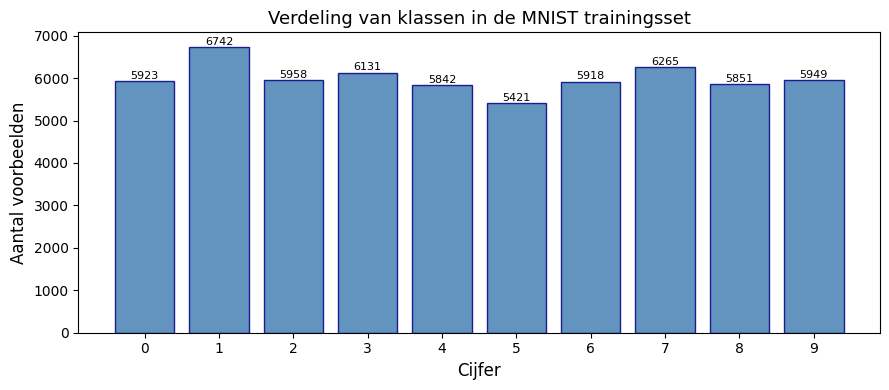

Gemiddelde pixelwaarde : 33.32
Standaardafwijking     : 78.57


In [3]:
uniek, aantal = np.unique(y_train, return_counts=True)

print('Aantal voorbeelden per cijfer (trainingsset):')
print('-' * 35)
for cijfer, n in zip(uniek, aantal):
    print('  Cijfer', cijfer, ':', n)
print('-' * 35)
print('  Totaal  :', len(y_train))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(uniek, aantal, color='steelblue', edgecolor='navy', alpha=0.85)
ax.set_xlabel('Cijfer', fontsize=12)
ax.set_ylabel('Aantal voorbeelden', fontsize=12)
ax.set_title('Verdeling van klassen in de MNIST trainingsset', fontsize=13)
ax.set_xticks(range(10))
for i, n in zip(uniek, aantal):
    ax.text(i, n + 50, str(n), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Gemiddelde pixelwaarde :', round(X_train.mean(), 2))
print('Standaardafwijking     :', round(X_train.std(), 2))

### Observaties - Data beschrijving

- De dataset is **redelijk gebalanceerd**: elk cijfer heeft ongeveer 5.000-6.500 voorbeelden.
- Afbeeldingen zijn **28x28 pixels** met grijswaarden van 0 (zwart) tot 255 (wit).
- De gemiddelde pixelwaarde is laag (~33) - de achtergrond is grotendeels zwart.

## 4. Afbeeldingen bekijken - een voorbeeld per cijfer

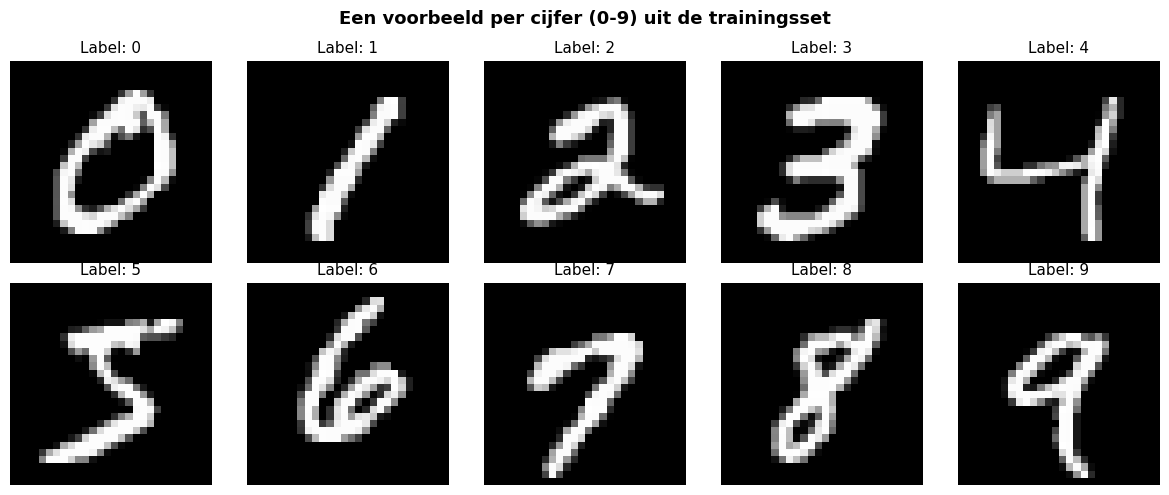

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Een voorbeeld per cijfer (0-9) uit de trainingsset', fontsize=13, fontweight='bold')

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title('Label: ' + str(digit), fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Vijf willekeurige voorbeelden van cijfer 3

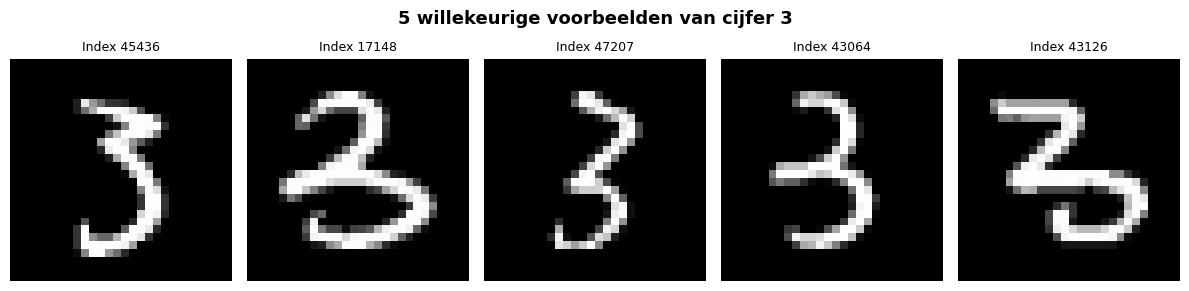

In [5]:
def toon_vijf_voorbeelden(digit, dataset_X, dataset_y, seed=42):
    np.random.seed(seed)
    indices = np.where(dataset_y == digit)[0]
    gekozen = np.random.choice(indices, 5, replace=False)

    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle('5 willekeurige voorbeelden van cijfer ' + str(digit),
                 fontsize=13, fontweight='bold')

    for i, idx in enumerate(gekozen):
        axes[i].imshow(dataset_X[idx], cmap='gray')
        axes[i].set_title('Index ' + str(idx), fontsize=9)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

toon_vijf_voorbeelden(3, X_train, y_train)

### Observaties - Cijfer 3

- De **breedte en hoogte** varieert sterk: sommige zijn smal en lang, andere breed en kort.
- De **bovenste boog** kan kleiner of groter zijn dan de onderste boog.
- Sommige 3-en hebben een duidelijk **middenpunt** (inkeping links), andere nauwelijks.
- De **lijndikte** verschilt: dun vs. dik handschrift.

## 6. Vergelijking: 4 vs. 9 en 1 vs. 7

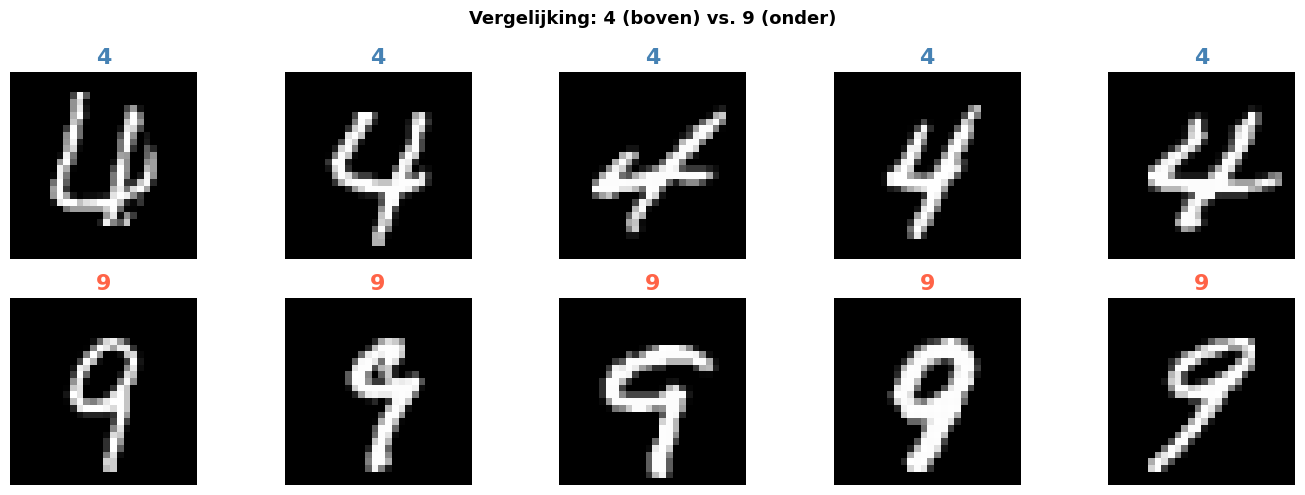

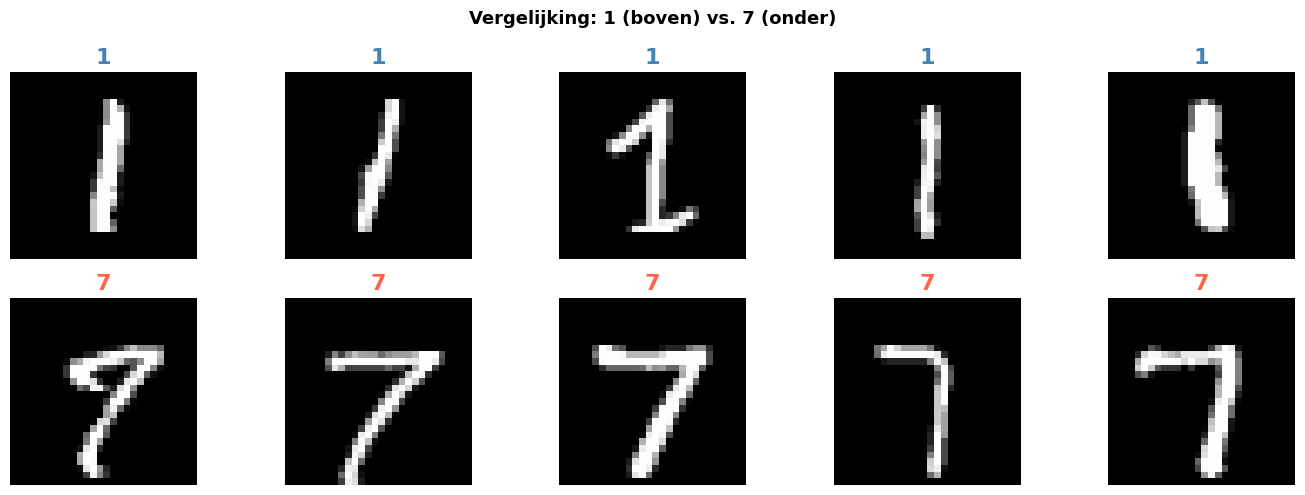

In [6]:
def vergelijk_paar(digit_a, digit_b, dataset_X, dataset_y, n=5, seed=42):
    np.random.seed(seed)
    idx_a = np.random.choice(np.where(dataset_y == digit_a)[0], n, replace=False)
    idx_b = np.random.choice(np.where(dataset_y == digit_b)[0], n, replace=False)

    fig, axes = plt.subplots(2, n, figsize=(14, 5))
    fig.suptitle('Vergelijking: ' + str(digit_a) + ' (boven) vs. ' + str(digit_b) + ' (onder)',
                 fontsize=13, fontweight='bold')

    for i in range(n):
        axes[0][i].imshow(dataset_X[idx_a[i]], cmap='gray')
        axes[0][i].set_title(str(digit_a), fontsize=16, color='steelblue', fontweight='bold')
        axes[0][i].axis('off')
        axes[1][i].imshow(dataset_X[idx_b[i]], cmap='gray')
        axes[1][i].set_title(str(digit_b), fontsize=16, color='tomato', fontweight='bold')
        axes[1][i].axis('off')

    plt.tight_layout()
    plt.show()

vergelijk_paar(4, 9, X_train, y_train)
vergelijk_paar(1, 7, X_train, y_train)

### Observaties - 4 vs. 9

- Beide hebben een **gesloten bovenlus** - dit is de kern van de verwarring.
- Het verschil: bij een **4** gaat de verticale lijn door de lus; bij een **9** hangt de staart eronder.

### Observaties - 1 vs. 7

- Sommige 1-en hebben een schuine bovenkap - dan lijkt het bijna op een 7.
- Het verschil zit in de **horizontale bovenlijn** van de 7, die bij een 1 ontbreekt.

## 7. Variatie in schrijfstijl per cijfer

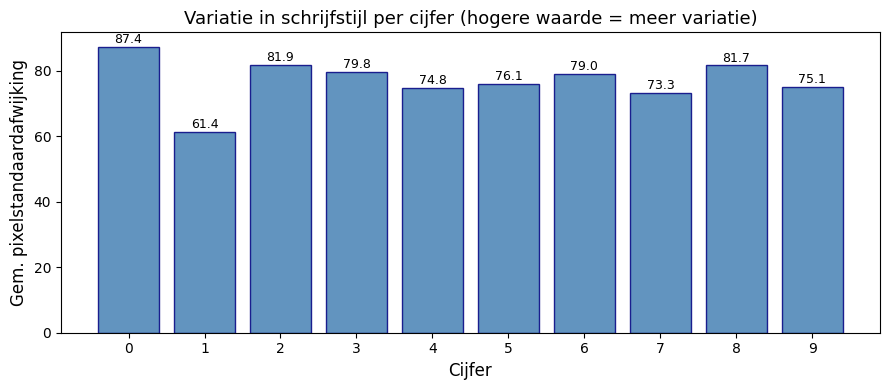

Meest variabel (slordigst)   : cijfer 0   std = 87.44
Minst variabel (consistentst): cijfer 1   std = 61.37


In [7]:
std_per_cijfer = []

for digit in range(10):
    subset = X_train[y_train == digit].astype(float)
    gemiddelde_std = subset.std(axis=(1, 2)).mean()
    std_per_cijfer.append(gemiddelde_std)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(10), std_per_cijfer, color='steelblue', edgecolor='navy', alpha=0.85)
ax.set_xlabel('Cijfer', fontsize=12)
ax.set_ylabel('Gem. pixelstandaardafwijking', fontsize=12)
ax.set_title('Variatie in schrijfstijl per cijfer (hogere waarde = meer variatie)', fontsize=13)
ax.set_xticks(range(10))
for bar, val in zip(bars, std_per_cijfer):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(round(val, 1)), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

meest = np.argmax(std_per_cijfer)
minst = np.argmin(std_per_cijfer)
print('Meest variabel (slordigst)   : cijfer', meest, '  std =', round(std_per_cijfer[meest], 2))
print('Minst variabel (consistentst): cijfer', minst, '  std =', round(std_per_cijfer[minst], 2))

## 8. Gemiddeld prototype per cijfer

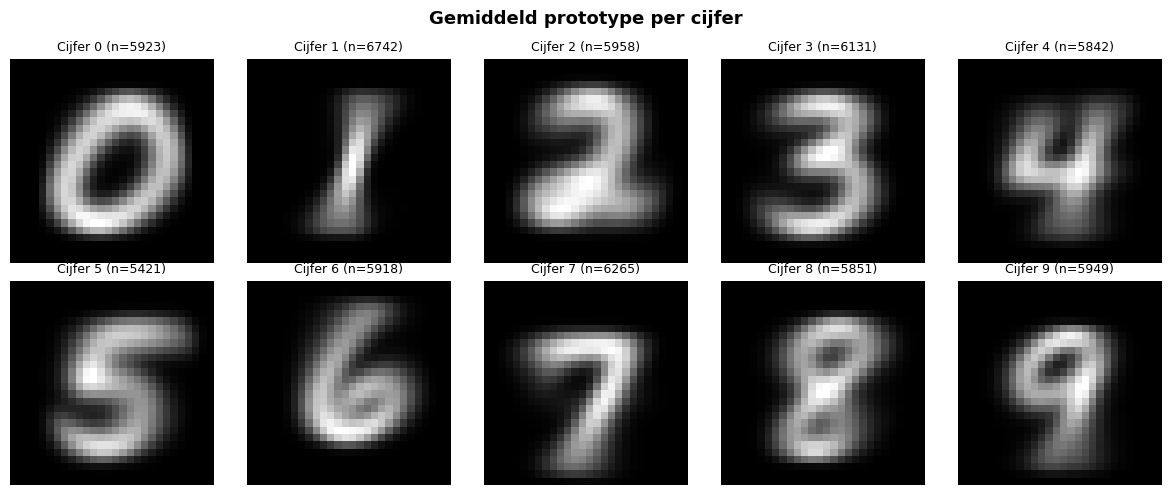

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Gemiddeld prototype per cijfer', fontsize=13, fontweight='bold')

for digit in range(10):
    subset = X_train[y_train == digit].astype(float)
    gemiddeld = subset.mean(axis=0)
    ax = axes[digit // 5][digit % 5]
    ax.imshow(gemiddeld, cmap='gray')
    ax.set_title('Cijfer ' + str(digit) + ' (n=' + str(len(subset)) + ')', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Conclusies

**Waarom is classificatie lastig?**

1. **Grote intra-klasse variatie** - Een cijfer wordt op totaal verschillende manieren geschreven.
2. **Visueel gelijkende paren** - 4 vs. 9, 1 vs. 7, 3 vs. 8, 5 vs. 6.
3. **Lage resolutie (28x28)** - Subtiele details gaan verloren.
4. **Schrijfstijl verschilt per persoon** - Cultuur en gewoontes beinvloeden handschrift.